<a href="https://colab.research.google.com/github/Cnshimba/AI_EIARI4A_2026/blob/main/week7_exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Classification Dataset: Fashion MNIST

Fashion MNIST is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes (e.g., T-shirt, Trouser, Pullover, Dress, etc.). It's often used as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms, but it's more challenging than MNIST.

**Why it's good for ANN classification:**
*   **Image Data:** Introduces you to working with image data, which is a primary application of ANNs (especially Convolutional Neural Networks, CNNs).
*   **Multi-class Classification:** A good problem for developing multi-class classification models.
*   **Built-in Keras support:** Easy to load directly from Keras.

Here's how to load it using `keras.datasets`:

In [ ]:
import tensorflow as tf

# Load the Fashion MNIST dataset
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = tf.keras.datasets.fashion_mnist.load_data()

print("Fashion MNIST Training Features (X_train_fashion):")
print(f"Shape of training features: {X_train_fashion.shape}")
print(f"Shape of training labels: {y_train_fashion.shape}")
print("\nFashion MNIST Test Features (X_test_fashion):")
print(f"Shape of test features: {X_test_fashion.shape}")
print(f"Shape of test labels: {y_test_fashion.shape}")

import matplotlib.pyplot as plt

# Display the first image and its label
plt.imshow(X_train_fashion[0], cmap='gray')
plt.title(f"Label: {y_train_fashion[0]}")
plt.axis('off')
plt.show()


In [14]:
import pandas as pd

# Assuming X_train_full is already loaded as a numpy array
X_train_full_df = pd.DataFrame(X_train_full)

print("First 5 rows of X_train_full:")
display(X_train_full_df.head())

First 5 rows of X_train_full:


,0,1,2,3,4,5,6,7
0,-118.269997,34.090000,52.0,2327.0,555.0,1048.0,491.0,3.7847
1,-118.360001,33.959999,21.0,1802.0,556.0,1286.0,557.0,2.7284
2,-122.389999,37.759998,52.0,1877.0,427.0,712.0,398.0,3.9722
3,-117.949997,33.919998,11.0,3127.0,706.0,1594.0,694.0,4.3426
4,-122.519997,37.919998,24.0,421.0,64.0,163.0,75.0,14.5833



### 2. Regression Dataset: California Housing Prices

This dataset contains aggregated data about houses in California districts. It's a classic choice for regression tasks, where the goal is to predict the median house value based on various features like population, median income, house age, etc. It's clean, well-structured, and easy to load.

**Why it's good for ANN regression:**
*   **Numerical Features:** All features are numerical, suitable for direct input into ANNs.
*   **Clear Target:** The target variable (median house value) is continuous.
*   **Moderate Size:** Large enough to demonstrate ANN capabilities but small enough to train quickly on a CPU.


Here's how to load it using `sklearn.datasets`:



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error
import numpy as np

In [2]:



# Load the dataset
housing = fetch_california_housing(as_frame=True)
X_housing, y_housing = housing.data, housing.target

print("California Housing Features (X):")
display(X_housing.head())
print("California Housing Target (y):")
display(y_housing.head())
print(f"Shape of features: {X_housing.shape}")
print(f"Shape of target: {y_housing.shape}")

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 2. Feature Scaling
# It's important to scale features for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFirst 5 rows of scaled X_train_scaled:")
display(pd.DataFrame(X_train_scaled).head())

California Housing Features (X):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


California Housing Target (y):


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


Shape of features: (20640, 8)
Shape of target: (20640,)
X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)

First 5 rows of scaled X_train_scaled:


,0,1,2,3,4,5,6,7
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


Training median: 1.7985
Baseline MAE: 0.8740399224806202


In [13]:
print(y_train.median())

1.7985


In [12]:
print(y_housing.median())

1.797


In [5]:
housing.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

Now that the data is prepared, let's define and train a new ANN model using this scaled data:

For the first layer of a Keras `Sequential` model (and often for other model types as well, though the syntax might differ), you must tell the model the shape of the data it should expect for a single input sample. This is typically done using the `input_shape` argument.

Here's why it's crucial:

1. **Model Building**: Keras needs this information to correctly build the internal structure of your neural network. It uses the `input_shape` to determine the number of weights and biases for the connections between the input layer and the first hidden layer.

2. **Compatibility** : It ensures that the model can correctly receive and process your data. If the `input_shape` doesn't match the actual shape of your input samples (excluding the batch dimension), you'll encounter errors during training or prediction.

While Keras can sometimes infer the `input_shape` if you define the input layer explicitly (e.g., `tf.keras.Input(shape=(num_features,)))` or when using the functional API, for a Sequential model where your first layer is a Dense layer, input_shape is the standard and necessary way to provide this information.


`input_shape=X_train_scaled.shape[1:]:` This part, `input_shape=(8,)`, is crucial and must correctly tell the model how many features are in each input sample. If your data has 8 features, input_shape should reflect that.

`tf.keras.layers.Dense(X, ...):` The X inside Dense(X, ...) specifies the number of neurons (or units) in that particular hidden layer. This is a hyperparameter that you, as the model designer, choose. It can be 8, 30, 64, 128, or any other reasonable positive integer.

* Why would you choose something other than the number of features? The neurons in hidden layers are responsible for learning complex patterns and transformations of the input data. Having more or fewer neurons than the input features allows the network to project the data into a different dimensional space, potentially capturing more intricate relationships.

* In this example:
When you see `Dense(30, ...):` the first hidden layer has 30 neurons. It took 8 input features and transformed them into 30 outputs.





In [6]:
# 3. Define the Keras model (similar to model_00, but adjusted for potentially scaled data)
model_housing = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=X_train_scaled.shape[1:]),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])







/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Before the neural network can start learning from data, it needs to know how to measure its performance and how to improve itself.

In your code, the compile method takes three key arguments:

1. Loss Function `(loss=tf.keras.losses.MeanSquaredError()):` This is the model's 'ruler.' It calculates the difference between the model's prediction and the actual target value. For regression (like predicting house prices), **Mean Squared Error (MSE)** is standard. It squares the errors, meaning larger mistakes are penalized much more heavily than small ones.

2. Optimizer `(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)):` ***If the loss function tells the model how wrong it is, the optimizer is the 'driver' that decides how to fix it***. It uses the loss value to adjust the weights of the neurons. Adam is a very popular choice because it automatically adjusts the learning rate as it trains, making it efficient and stable.

3. Metrics `(metrics=[tf.keras.metrics.MeanAbsoluteError()]):` These are purely for you to read. While the model uses the Loss to update its weights, it reports the Metric so you can understand the error in a more human-readable way. **Mean Absolute Error (MAE)** tells you exactly how many dollars (in thousands) the model is off by on average.

In [7]:
# 4. Compile the model
model_housing.compile(
    loss=tf.keras.losses.MeanSquaredError(), # Using MSE is common for regression
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

Here is a breakdown of what happens when you call model_housing.fit():

* `X_train_scaled, y_train:` These are your scaled features and the correct target prices. The model looks at the features, makes a guess, compares it to the target, and then uses the 'Optimizer' to adjust its internal weights.
* `epochs=100:` An epoch is one full pass through the entire training dataset. By setting this to 100, you are giving the model 100 opportunities to see the data and refine its patterns.
* `validation_data=(X_test_scaled, y_test):` This is a crucial addition. By providing this, Keras calculates the loss and MAE on the test data at the end of every epoch. This allows you to monitor if the model is performing well on new data in real-time or if it's starting to overfit (getting better at training data but worse at test data).
* `verbose=2:` This controls the output style. It prints one line per epoch, showing you the training loss, training MAE, validation loss, and validation MAE so you can track progress.
* `history:` All the performance numbers from those 100 rounds are saved in this variable, which we later used to plot the learning curves.

In [8]:
# 5. Train the model
print("\nTraining the model...")
history = model_housing.fit(
    X_train_scaled, y_train, epochs=100, validation_data=(X_test_scaled, y_test), verbose=0
)


Training the model...


### 7. Why We Compute a Median Baseline

In this step, we are building a **simple baseline model** to evaluate how well our machine learning model performs.

#### What are we doing?

```python
median_value = y_train.median()
baseline_predictions = np.full(len(y_test), median_value)
mae_baseline = mean_absolute_error(y_test, baseline_predictions)
```

* We calculate the **median house value** from the training data.
* We then pretend that **every house in the test set has this same value**.
* Finally, we compute the **Mean Absolute Error (MAE)** of these predictions.



#### Why do we use the median?

The median represents a **typical house price** and is:

* Less affected by extreme values (outliers)
* A fair “default guess” when no features are used



#### What does this baseline represent?

This baseline answers the question:

*“How well can we do if we ignore all features and just guess a constant value?”*

It is a **very simple model** — essentially a “no intelligence” model.



#### Why is this important?

Without a baseline, your model’s performance has **no context**.

For example:

* If your ANN has MAE = 0.52 → is that good or bad?

Now compare:

* Baseline MAE ≈ 0.85
* ANN MAE ≈ 0.52

This shows your model is **significantly better than a naive guess**.



#### What insight does this give us?

* If your model **does not beat the baseline**, it is not learning anything useful.
* If it **beats the baseline significantly**, it means:

  * The model is extracting meaningful patterns from the data




In [ ]:
median_value = y_train.median()
baseline_predictions = np.full(len(y_test), median_value)
print("Training median:", median_value)
mae_baseline = mean_absolute_error(y_test, baseline_predictions)
print("Baseline MAE:", mae_baseline)

In [10]:
# 6. Evaluate the model on the test set
print("\nEvaluating the model on the test set...")
loss, mae = model_housing.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")


Evaluating the model on the test set...
Test Loss (MSE): 0.2914
Test MAE: 0.3726


### 8. Visualizing Training History

Plotting the training curves allows us to see how the loss and metrics evolve over epochs. This is useful for checking if the model has converged or if there is any evidence of overfitting.

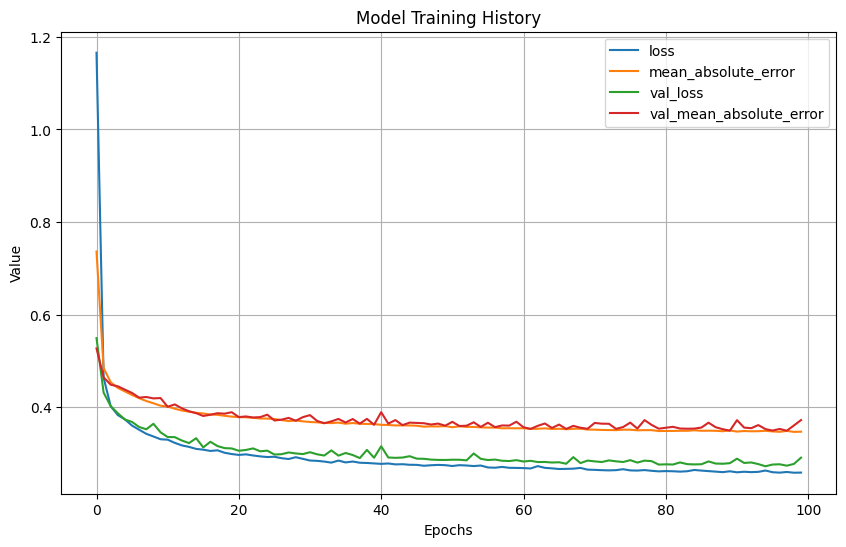

In [11]:
import matplotlib.pyplot as plt

# Plot training loss and MAE
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.title("Model Training History")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.grid(True)
plt.show()

This graph shows the 'Learning Curve' of this neural network. Here is how to interpret the results:

* **The Y-axis (Value)**: Represents the error. You want these lines to be as low as possible.
* **The X-axis (Epochs):** Shows the progress through 100 rounds of training.
* **The Blue Line (Loss)**: This is the Mean Squared Error (MSE). Notice how it drops extremely fast in the first 10-20 epochs and then levels off. This 'elbow' shape indicates the model quickly found the general pattern and spent the rest of the time fine-tuning.
* **The Orange Line (Mean Absolute Error):** This tells you the error in terms of house prices. Since it follows the blue line closely and stays flat toward the end, it confirms the model has converged—meaning more training probably won't improve it much further.

Because the lines are smooth and didn't start going back up, it suggests the model learned well without significant overfitting during these 100 epochs.